Part 1. 

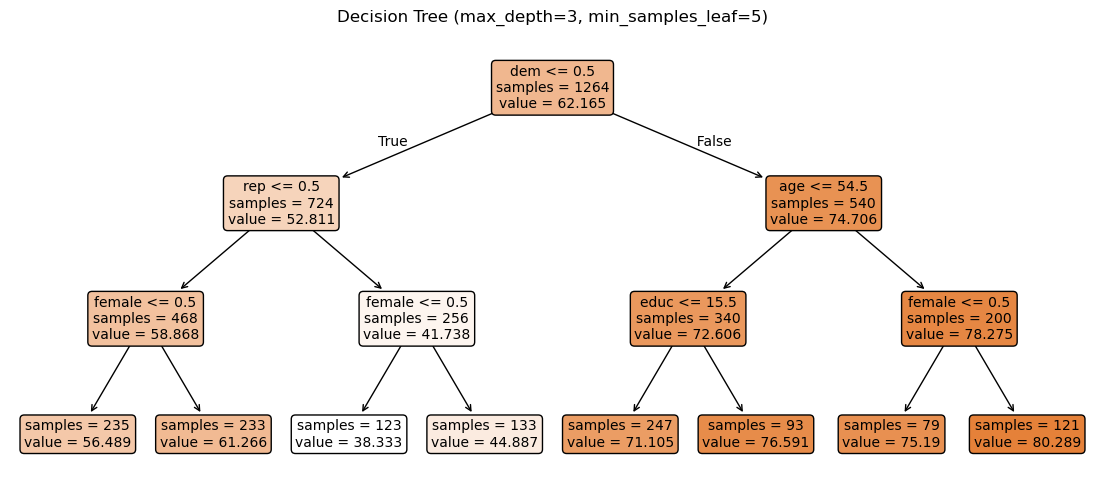

Part 1 - Decision Tree test MSE: 396.1937


In [8]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import randint as sp_randint

# 1) Load data
df = pd.read_csv('biden.csv')
df.head()

# Prepare X, y
y = df['biden']
X = df[['female', 'age', 'dem', 'rep', 'educ']]

# 2) Train/test split (70/30) with seed=25
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=25
)

# ---------- PART 1: Fit decision tree (max_depth=3, min_samples_leaf=5) ----------
dt_default = DecisionTreeRegressor(max_depth=3, min_samples_leaf=5, random_state=25)
dt_default.fit(X_train, y_train)

# Plot the tree
plt.figure(figsize=(14,6))
plot_tree(dt_default,
          feature_names=X.columns,
          filled=True,
          rounded=True,
          fontsize=10,
          impurity=False)
plt.title('Decision Tree (max_depth=3, min_samples_leaf=5)')
plt.show()

# Test MSE
y_pred_dt = dt_default.predict(X_test)
mse_dt = mean_squared_error(y_test, y_pred_dt)
print(f"Part 1 - Decision Tree test MSE: {mse_dt:.4f}")

The simple decision tree with max_depth=3 and min_samples_leaf=5 produced a test MSE of about 396. The first split separates respondents by whether they are Democrats, showing that political affiliation is the main factor in explaining feelings toward Joe Biden. Among non-Democrats, the model next splits by Republican identification, with Republicans showing much lower average scores. On the Democratic side, the tree splits by age and education, suggesting that older and more educated Democrats tend to feel more positively. The modest MSE shows that the shallow tree captures broad trends but not all the individual variation.

Part 2.

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the data again
df = pd.read_csv('biden.csv')

# Define predictors and target
y = df['biden']
X = df[['female', 'age', 'dem', 'rep', 'educ']]

# Split into training (70%) and test (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=25
)


Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best params (RandomizedSearchCV): {'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 9}
Best CV MSE (negative->positive): 404.7099
Best estimator attributes:
 - max_depth: 3
 - min_samples_split: 9
 - min_samples_leaf: 2
Simple tree test MSE: 396.1937
Tuned tree test MSE:  394.7620
Test MSE change (tuned - simple): -1.4317
Simple tree stats: {'n_nodes': 15, 'max_depth': 3, 'n_leaves': 8}
Tuned tree stats:  {'n_nodes': 15, 'max_depth': 3, 'n_leaves': 8}


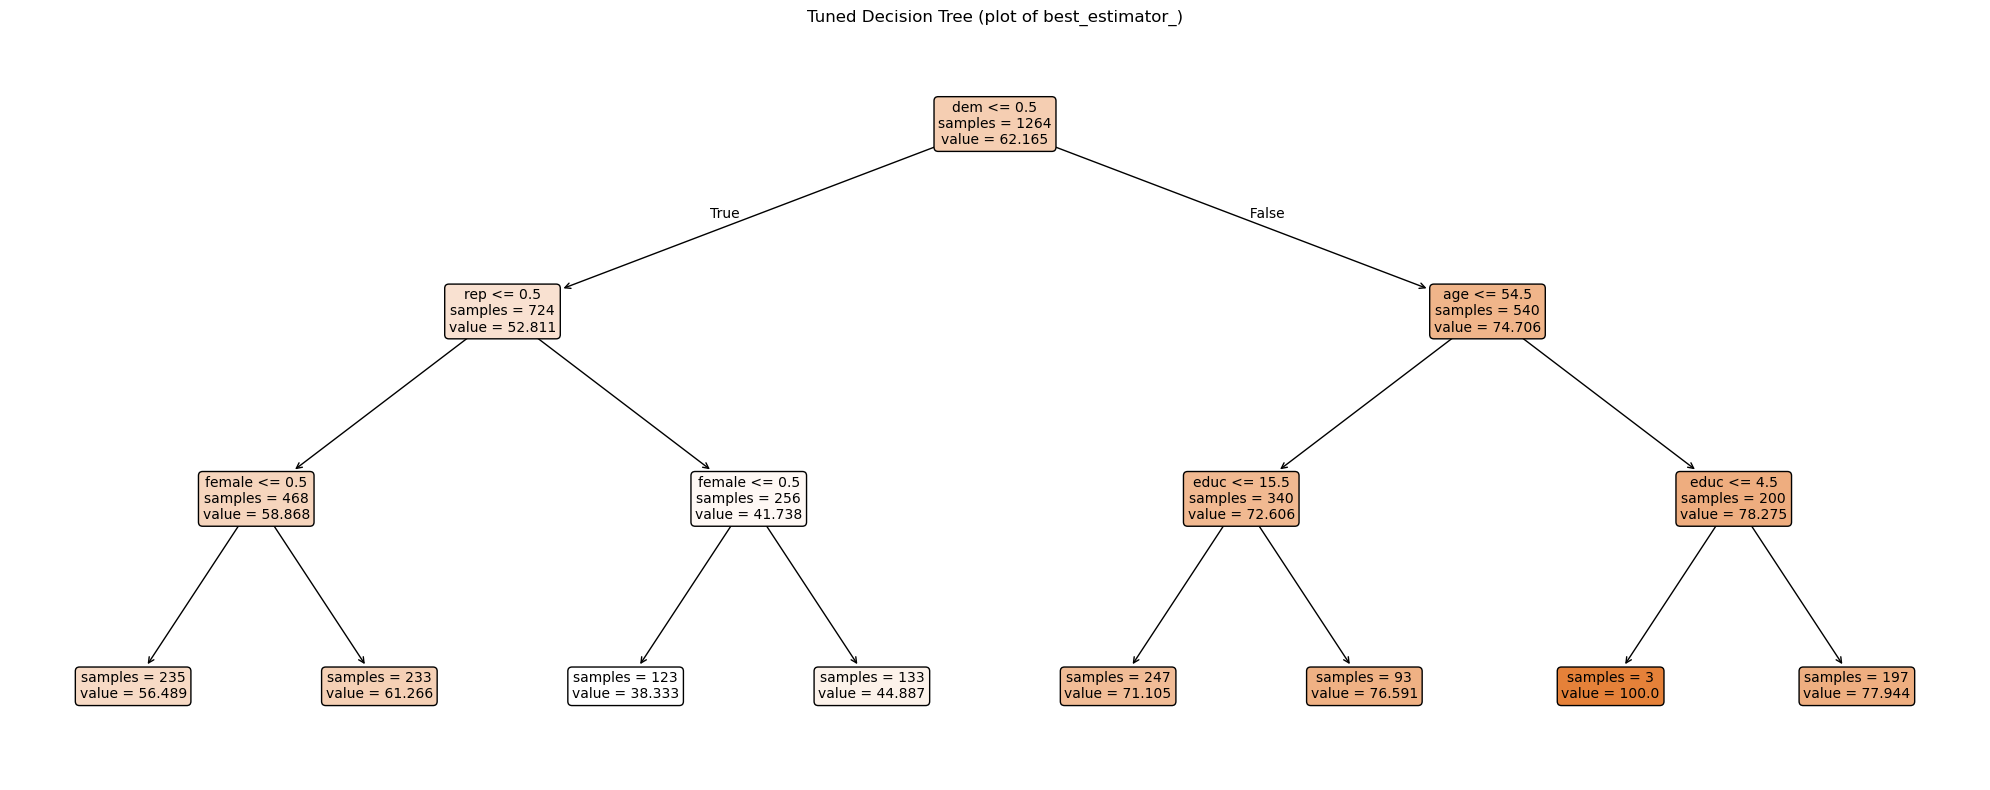

Saved DOT file to best_tree.dot (convert with Graphviz for a nicer image).


In [4]:
# Run this whole cell (it reloads data + runs the same RandomizedSearchCV if needed)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import randint as sp_randint
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_graphviz
from sklearn.metrics import mean_squared_error
import os

# 1) load & split (same seed as before)
df = pd.read_csv('biden.csv')
y = df['biden']
X = df[['female', 'age', 'dem', 'rep', 'educ']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=25)

# 2) random search parameters (same as assignment)
param_dist_tree = {
    "max_depth": [3, 10],
    "min_samples_split": sp_randint(2, 20),
    "min_samples_leaf": sp_randint(2, 20)
}
dt_model = DecisionTreeRegressor(random_state=25)
rand_search_dt = RandomizedSearchCV(
    estimator=dt_model,
    param_distributions=param_dist_tree,
    n_iter=100,
    cv=5,
    random_state=25,
    n_jobs=-1,
    scoring='neg_mean_squared_error',
    verbose=1,
    refit=True  # ensure best_estimator_ is refit on full training set (default True)
)

# 3) fit the search (if you already ran it and have rand_search_dt in memory, skip fit)
rand_search_dt.fit(X_train, y_train)

# 4) report results
best_params = rand_search_dt.best_params_
best_cv_mse = -rand_search_dt.best_score_
print("Best params (RandomizedSearchCV):", best_params)
print(f"Best CV MSE (negative->positive): {best_cv_mse:.4f}")

best_dt = rand_search_dt.best_estimator_
print("Best estimator attributes:")
print(" - max_depth:", best_dt.get_params()['max_depth'])
print(" - min_samples_split:", best_dt.get_params()['min_samples_split'])
print(" - min_samples_leaf:", best_dt.get_params()['min_samples_leaf'])

# 5) compute test MSE for both simple tree and tuned tree for direct comparison
# Simple tree (prof-specified)
simple_dt = DecisionTreeRegressor(max_depth=3, min_samples_leaf=5, random_state=25)
simple_dt.fit(X_train, y_train)
y_pred_simple = simple_dt.predict(X_test)
mse_simple = mean_squared_error(y_test, y_pred_simple)

# Tuned tree (best estimator refit on full training)
y_pred_tuned = best_dt.predict(X_test)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)

print(f"Simple tree test MSE: {mse_simple:.4f}")
print(f"Tuned tree test MSE:  {mse_tuned:.4f}")
print(f"Test MSE change (tuned - simple): {mse_tuned - mse_simple:.4f}")

# 6) tree complexity diagnostics
def tree_stats(tree, X):
    # number of leaves and depth
    n_nodes = tree.tree_.node_count
    max_depth = tree.tree_.max_depth
    # leaf count
    is_leaf = (tree.tree_.children_left == -1) & (tree.tree_.children_right == -1)
    leaf_count = np.sum(is_leaf)
    return {"n_nodes": n_nodes, "max_depth": max_depth, "n_leaves": int(leaf_count)}

print("Simple tree stats:", tree_stats(simple_dt, X_train))
print("Tuned tree stats: ", tree_stats(best_dt, X_train))

# 7) Plot tuned tree (cleaner: hide impurity)
plt.figure(figsize=(20,8))
plot_tree(best_dt,
          feature_names=X.columns,
          filled=True,
          rounded=True,
          fontsize=10,
          impurity=False)   # hides squared_error in boxes
plt.title('Tuned Decision Tree (plot of best_estimator_)')
plt.tight_layout()
plt.show()

# 8) Optional: save a higher-quality Graphviz PNG (requires graphviz & pydotplus installed)
try:
    dot = export_graphviz(best_dt, out_file=None,
                          feature_names=X.columns,
                          filled=True, rounded=True, impurity=False)
    # If graphviz/pydotplus is installed, you can convert dot to png externally.
    # We write the dot text to a file so you can convert it locally if you want:
    with open("best_tree.dot", "w") as f:
        f.write(dot)
    print("Saved DOT file to best_tree.dot (convert with Graphviz for a nicer image).")
except Exception as e:
    print("Could not export graphviz .dot (Graphviz may not be installed). Error:", e)


The random search picked a tree with max_depth=3, min_samples_leaf=2, and min_samples_split=9. Its cross-validated MSE was about 404.7, and the test MSE was around 394.8. The tuned tree has about the same depth and number of leaves as the simple tree, so the overall structure didn’t really change. The small drop in test error (from 396.2 to 394.8) is minor and could just be due to normal variation in the data or how the folds were split. In general, the tuning didn’t make the model noticeably more complex or accurate, which suggests that the original shallow tree was already doing a reasonable job at capturing the main relationships.

Part 3.

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best hyperparameters (Random Forest): {'max_depth': 3, 'max_features': 3, 'min_samples_leaf': 19, 'min_samples_split': 2, 'n_estimators': 200}
Best CV MSE (positive): 398.2014
Tuned Random Forest test MSE: 391.5526


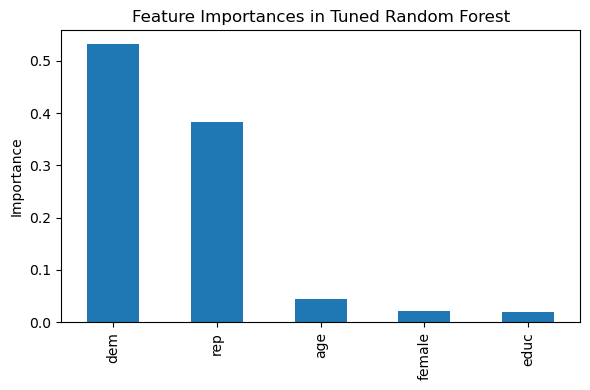

In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error
from scipy.stats import randint as sp_randint

# Parameter grid for random forest
param_dist_rf = {
    "n_estimators": [10, 200],
    "max_depth": [3, 10],
    "min_samples_split": sp_randint(2, 20),
    "min_samples_leaf": sp_randint(2, 20),
    "max_features": sp_randint(1, 5)
}

rf_model = RandomForestRegressor(random_state=25)

# Randomized search setup
rand_search_rf = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist_rf,
    n_iter=100,
    cv=5,
    random_state=25,
    n_jobs=-1,
    scoring='neg_mean_squared_error',
    verbose=1
)

# Fit the random search
rand_search_rf.fit(X_train, y_train)

# Extract results
best_params_rf = rand_search_rf.best_params_
best_cv_mse_rf = -rand_search_rf.best_score_

print("Best hyperparameters (Random Forest):", best_params_rf)
print(f"Best CV MSE (positive): {best_cv_mse_rf:.4f}")

# Evaluate tuned random forest on the test set
best_rf = rand_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
test_mse_rf = mean_squared_error(y_test, y_pred_rf)

print(f"Tuned Random Forest test MSE: {test_mse_rf:.4f}")

# Optional: feature importance plot
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(6,4))
importances.plot(kind='bar')
plt.title("Feature Importances in Tuned Random Forest")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


The tuned random forest used 200 trees with a maximum depth of 3, a maximum of 3 features per split, and fairly large leaves (19 samples each). It achieved a cross-validated MSE of about 398.2 and a test MSE of roughly 391.6, which was the lowest among all models. The feature importance results show that party affiliation (Democrat and Republican variables) are the biggest factors in explaining Biden ratings, while age, education, and gender matter much less. The random forest’s slightly lower test error compared to the single trees shows that averaging many shallow trees helps stabilize predictions and reduce noise without overfitting.